Epoch 1/5
235/235 [==============================] - 2s 7ms/step - loss: 0.2434
Epoch 2/5
235/235 [==============================] - 2s 7ms/step - loss: 0.1419
Epoch 3/5
235/235 [==============================] - 2s 6ms/step - loss: 0.1173
Epoch 4/5
235/235 [==============================] - 2s 7ms/step - loss: 0.1032
Epoch 5/5
235/235 [==============================] - 2s 6ms/step - loss: 0.0946
Epoch 1/5
235/235 [==============================] - 2s 6ms/step - loss: 0.2601
Epoch 2/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1743
Epoch 3/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1503
Epoch 4/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1383
Epoch 5/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1312
Epoch 1/5
235/235 [==============================] - 2s 6ms/step - loss: 237.0616
Epoch 2/5
235/235 [==============================] - 1s 6ms/step - loss: 186.0829
Epoch 3/5
235/235 [=================

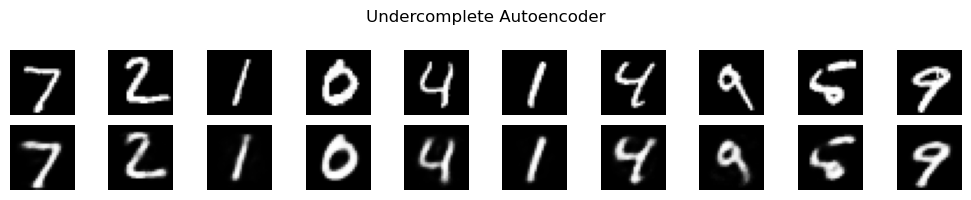

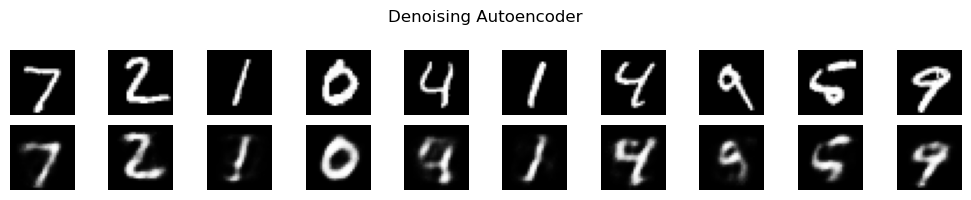

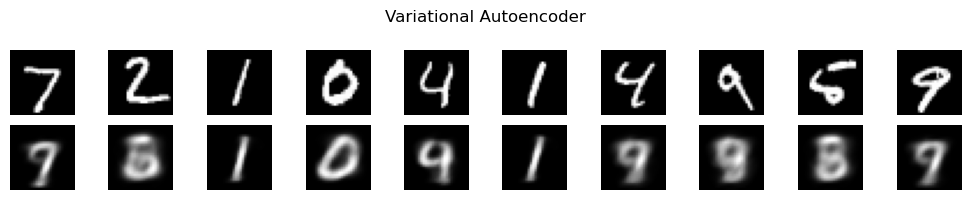

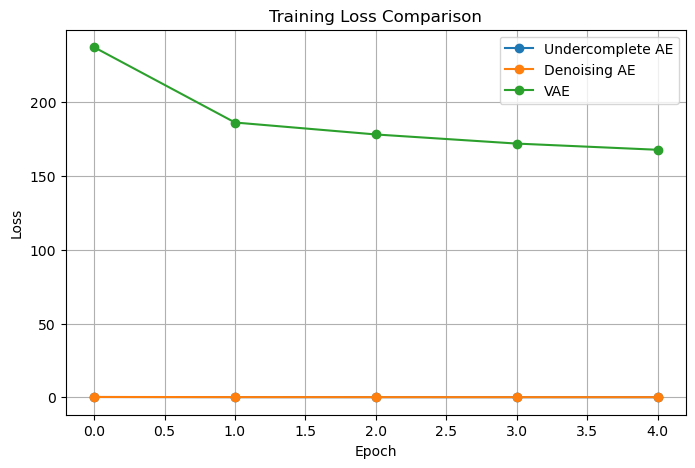

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

def add_noise(x):
    return np.clip(x + 0.5 * np.random.randn(*x.shape), 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

encoder_uc = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

decoder_uc = models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

ucae = models.Sequential([encoder_uc, decoder_uc])

ucae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

hist1 = ucae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)

encoder_dn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

decoder_dn = models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

dnae = models.Sequential([encoder_dn, decoder_dn])

dnae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

hist2 = dnae.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = layers.Input(shape=(28, 28, 1))

x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(2, name="z_mean")(x)
z_log_var = layers.Dense(2, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(
    inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

latent_inputs = layers.Input(shape=(2,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(784, activation="sigmoid")(x)

outputs = layers.Reshape((28, 28, 1))(x)

decoder = tf.keras.Model(
    latent_inputs,
    outputs,
    name="decoder"
)

class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstruction)
        ) * 784

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        self.add_loss(recon_loss + kl_loss)

        return reconstruction

vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

hist3 = vae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)

def show_imgs(orig, recon, title):

    plt.figure(figsize=(10, 2))

    n = min(10, len(orig))

    for i in range(n):

        plt.subplot(2, n, i + 1)

        img = orig[i].squeeze()

        plt.imshow(img, cmap='gray')
        plt.axis('off')

        plt.subplot(2, n, i + n + 1)

        img = recon[i].squeeze()

        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

ucae_recon = ucae.predict(x_test)

dnae_recon = dnae.predict(x_test_noisy)

vae_recon = vae.predict(x_test)

show_imgs(x_test, ucae_recon, "Undercomplete Autoencoder")

show_imgs(x_test, dnae_recon, "Denoising Autoencoder")

show_imgs(x_test, vae_recon, "Variational Autoencoder")

plt.figure(figsize=(8,5))

plt.plot(hist1.history['loss'], marker='o', label='Undercomplete AE')

plt.plot(hist2.history['loss'], marker='o', label='Denoising AE')

plt.plot(hist3.history['loss'], marker='o', label='VAE')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()